<a id="titulo"></a>

# ***Asistente experto en analitica de futbol profesional con Gemini, RAG y LangGraph***

Proyecto final de IA Generativa: construccion de un agente experto capaz de responder preguntas sobre analitica de futbol profesional usando una base de conocimiento vectorial propia, Gemini como LLM, Gemini Embeddings, ChromaDB, LangGraph y memoria conversacional.

**Dominio elegido:** scouting y analitica avanzada de jugadores de futbol profesional en las cinco grandes ligas europeas durante la temporada 2024-2025.


<!-- INDICE_GENERADO -->
<a id="indice"></a>

## ***Indice del notebook***

Usa este indice para ir directamente a cada seccion del proyecto.

- [Asistente experto en analitica de futbol profesional con Gemini, RAG y LangGraph](#titulo)
- [1. Instalacion de dependencias](#sec-1)
- [2. Imports y configuracion del entorno](#sec-2)
- [3. Rutas del proyecto](#sec-3)
- [4. Inicializacion de Gemini](#sec-4)
- [5. Prueba minima del LLM](#sec-5)
- [6. Carga inicial del dataset y de los PDFs](#sec-6)
- [7. Revision rapida de cobertura de datos](#sec-7)
- [8. Arquitectura MVP del asistente](#sec-8)
- [9. System prompt personalizado](#sec-9)
  - [9.1 Justificacion del system prompt](#sec-9-1)
- [10. Preparacion de documentos PDF para RAG](#sec-10)
  - [10.1 Carga de paginas PDF como documentos](#sec-10-1)
- [11. Chunking de los PDFs](#sec-11)
- [12. Creacion de la base vectorial con ChromaDB](#sec-12)
  - [12.1 Prueba aislada de embeddings antes de indexar](#sec-12-1)
  - [12.2 Indexacion en ChromaDB](#sec-12-2)
  - [12.3 Recarga de la coleccion existente](#sec-12-3)
- [13. Prueba del retriever](#sec-13)
- [14. RAG basico con Gemini](#sec-14)
  - [14.1 Prueba conceptual del RAG](#sec-14-1)
  - [14.2 Inspeccion de documentos usados](#sec-14-2)
  - [14.3 Prueba sobre metricas de porteros](#sec-14-3)
- [15. Herramienta SQL para consultar el CSV](#sec-15)
  - [15.1 Crear una base SQLite temporal desde pandas](#sec-15-1)
  - [15.2 Esquema del CSV para el prompt SQL](#sec-15-2)
  - [15.3 Generar SQL con prompting](#sec-15-3)
  - [15.4 Ejecutar SQL de forma segura](#sec-15-4)
  - [15.5 Herramienta completa: pregunta a resultado SQL](#sec-15-5)
  - [15.6 Pruebas de la herramienta SQL](#sec-15-6)
- [16. Agente final con LangGraph, SQL y memoria](#sec-16)
  - [16.1 Diseño del grafo final](#sec-16-1)
  - [16.2 Nodos del grafo final](#sec-16-2)
  - [16.3 Construccion del grafo con MemorySaver](#sec-16-3)
  - [16.4 Visualizacion del grafo final](#sec-16-4)
  - [16.5 Funcion de chat con memoria](#sec-16-5)
  - [16.6 Pruebas del agente final](#sec-16-6)
  - [16.7 Verificacion de memoria y fuentes](#sec-16-7)
- [17. Interaccion en el notebook y ejemplos documentados](#sec-17)
  - [17.1 Celda interactiva de chat](#sec-17-1)
  - [17.2 Cinco preguntas de ejemplo documentadas](#sec-17-2)
- [Resultado de esta fase](#resultado-fase)
- [18. Conclusiones y mejoras futuras](#sec-18)
  - [18.1 Conclusiones](#sec-18-1)
  - [18.2 Mejoras futuras](#sec-18-2)


<a id="sec-1"></a>

## ***1. Instalacion de dependencias***

Ejecuta esta celda solo si tu entorno no tiene instaladas las librerias.


In [42]:
# Esta celda sirve para instalar las librerias si el entorno no las tiene.
# En local normalmente se instalan desde requirements.txt.
# En Google Colab conviene descomentar la linea siguiente y ejecutarla una vez.
!pip install -q langchain langchain-core langchain-community langchain-google-genai langchain-text-splitters langgraph chromadb python-dotenv pypdf pandas tabulate

<a id="sec-2"></a>

## ***2. Imports y configuracion del entorno***

Las claves y configuraciones sensibles se cargan desde `.env`. No se debe hardcodear la API key en el notebook.


In [43]:
# Path permite trabajar con rutas de archivos de forma robusta en Windows, Linux o Colab
from pathlib import Path
import os
import pandas as pd
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings

# Cargamos el archivo .env para que Python pueda leer GOOGLE_API_KEY y otros parametros
# override=True fuerza a usar el valor actual del .env aunque el kernel tuviera uno antiguo cargado
load_dotenv(override=True)

# Leemos la clave de Gemini desde el .env
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")
GEMINI_MODEL = os.getenv("GEMINI_MODEL", "gemini-2.5-flash").strip().strip('"')
GEMINI_EMBEDDING_MODEL = os.getenv("GEMINI_EMBEDDING_MODEL", "gemini-embedding-001").strip().strip('"')
CHROMA_DB_DIR = os.getenv("CHROMA_DB_DIR", "chroma_db").strip().strip('"')

# Si no hay API key, paramos el notebook con un error claro
if not GOOGLE_API_KEY:
    raise ValueError("No se encontro GOOGLE_API_KEY. Revisa el archivo .env")

# Mostramos informacion de configuracion sin imprimir la API key completa
print("API key cargada:", bool(GOOGLE_API_KEY))
print("Modelo Gemini:", GEMINI_MODEL)
print("Modelo embeddings:", GEMINI_EMBEDDING_MODEL)
print("Directorio Chroma:", CHROMA_DB_DIR)

API key cargada: True
Modelo Gemini: gemini-2.5-flash
Modelo embeddings: gemini-embedding-001
Directorio Chroma: chroma_db


<a id="sec-3"></a>

## ***3. Rutas del proyecto***

Centralizamos las rutas para que el notebook sea mas mantenible y pueda ejecutarse desde la carpeta `notebooks` o desde la raiz del proyecto.


In [44]:
# Path.cwd() devuelve la carpeta desde la que se esta ejecutando el notebook
NOTEBOOK_DIR = Path.cwd()

# Si ejecutamos el notebook desde la carpeta notebooks, la raiz del proyecto es el directorio padre
# Si lo ejecutamos desde la raiz del proyecto, PROJECT_ROOT sera la carpeta actual
if NOTEBOOK_DIR.name == "notebooks":
    PROJECT_ROOT = NOTEBOOK_DIR.parent
else:
    PROJECT_ROOT = NOTEBOOK_DIR

# Carpeta donde estan los datos del proyecto
DATA_DIR = PROJECT_ROOT / "data"

# Ruta del CSV con estadisticas de jugadores
CSV_PATH = DATA_DIR / "players_data-2024_2025.csv"

# Lista de PDFs que formaran la base vectorial de conocimiento conceptual
PDF_PATHS = sorted(DATA_DIR.glob("*.pdf"))

# Ruta donde ChromaDB guardara los vectores de forma persistente
CHROMA_PATH = PROJECT_ROOT / CHROMA_DB_DIR

# Comprobamos que el CSV existe
if not CSV_PATH.exists():
    raise FileNotFoundError(f"No se encontro el CSV requerido: {CSV_PATH}")

# Comprobamos que hay al menos 3 PDFs, como pide el enunciado
if len(PDF_PATHS) < 3:
    raise FileNotFoundError("Se necesitan al menos 3 PDFs en la carpeta data para la base de conocimiento.")

# Imprimimos las rutas para verificar que el notebook esta leyendo los archivos correctos
print("PROJECT_ROOT:", PROJECT_ROOT)
print("CSV:", CSV_PATH)
print("PDFs encontrados:", len(PDF_PATHS))
for pdf_path in PDF_PATHS:
    print("-", pdf_path.name)
print("ChromaDB:", CHROMA_PATH)

PROJECT_ROOT: c:\Users\User\Documents\Master Data Science_IA\IA_GENERATIVA\Asistente_Experto_LLM_Oscar_Fernandez\Asistente_Experto_LLM_Oscar_Fernandez_Evolve
CSV: c:\Users\User\Documents\Master Data Science_IA\IA_GENERATIVA\Asistente_Experto_LLM_Oscar_Fernandez\Asistente_Experto_LLM_Oscar_Fernandez_Evolve\data\players_data-2024_2025.csv
PDFs encontrados: 3
- 01_metricas_base_tiro_xg.pdf
- 02_metricas_pase_creacion_posesion.pdf
- 03_metricas_defensa_porteros_modelado_rag.pdf
ChromaDB: c:\Users\User\Documents\Master Data Science_IA\IA_GENERATIVA\Asistente_Experto_LLM_Oscar_Fernandez\Asistente_Experto_LLM_Oscar_Fernandez_Evolve\chroma_db


<a id="sec-4"></a>

## ***4. Inicializacion de Gemini***

Creamos dos componentes: el modelo conversacional para generar respuestas y el modelo de embeddings para indexar y recuperar informacion desde ChromaDB.


In [45]:
# Creamos el modelo de lenguaje Gemini para generar respuestas
llm = ChatGoogleGenerativeAI(
    # Modelo definido en .env, por ejemplo gemini-2.5-flash
    model=GEMINI_MODEL,
    # API key cargada desde .env
    google_api_key=GOOGLE_API_KEY,
    # Temperatura baja para respuestas mas consistentes y menos creativas
    temperature=0.5,
)

# Creamos el modelo de embeddings que convertira texto en vectores numericos
embeddings = GoogleGenerativeAIEmbeddings(
    # Modelo de embeddings definido en .env
    model=GEMINI_EMBEDDING_MODEL,
    # API key cargada desde .env
    google_api_key=GOOGLE_API_KEY,
)

# Confirmamos que ambos componentes se han creado
print("LLM inicializado:", GEMINI_MODEL)
print("Embeddings inicializados:", GEMINI_EMBEDDING_MODEL)

LLM inicializado: gemini-2.5-flash
Embeddings inicializados: gemini-embedding-001


<a id="sec-5"></a>

## ***5. Prueba minima del LLM***

Antes de construir el RAG, verificamos que Gemini responde correctamente. Esta prueba no usa todavia la base de conocimiento; solo valida conexion y configuracion.


In [46]:
# Prueba opcional del LLM.
# La dejamos comentada para ahorrar cuota de Gemini cuando se ejecuta todo el notebook.
# Descomenta estas lineas si quieres comprobar manualmente que Gemini responde.

# respuesta = llm.invoke("Explica en una frase que significa xG en futbol.")
# print(respuesta.content)


<a id="sec-6"></a>

## ***6. Carga inicial del dataset y de los PDFs***

El CSV se usara con pandas para consultar datos exactos de jugadores. Los PDFs se usaran como documentos de conocimiento para ChromaDB y el RAG.


In [47]:
# Cargamos el CSV de jugadores en un DataFrame de pandas
df = pd.read_csv(CSV_PATH)

# Mostramos dimensiones del dataset: filas y columnas
print("Dataset:", df.shape)

# Mostramos el numero total de columnas
print("Columnas:", len(df.columns))

# Mostramos los PDFs disponibles para la base vectorial
print("Documentos PDF para RAG:")
for pdf_path in PDF_PATHS:
    print("-", pdf_path.name)

# Visualizamos algunas columnas importantes para comprobar que el CSV se cargo bien
df[["Player", "Squad", "Comp", "Pos", "Age", "Min", "xG", "xAG", "PrgC", "PrgP"]].head()

Dataset: (2854, 267)
Columnas: 267
Documentos PDF para RAG:
- 01_metricas_base_tiro_xg.pdf
- 02_metricas_pase_creacion_posesion.pdf
- 03_metricas_defensa_porteros_modelado_rag.pdf


,Player,Squad,Comp,Pos,Age,Min,xG,xAG,PrgC,PrgP
0,Max Aarons,Bournemouth,eng Premier League,DF,24.0,86,0.0,0.0,1,8
1,Max Aarons,Valencia,es La Liga,"DF,MF",24.0,120,0.0,0.0,0,6
2,Rodrigo Abajas,Valencia,es La Liga,DF,21.0,65,0.1,0.0,3,2
3,James Abankwah,Udinese,it Serie A,"DF,MF",20.0,88,0.1,0.0,3,4
4,Keyliane Abdallah,Marseille,fr Ligue 1,FW,18.0,3,0.0,0.0,1,0


<a id="sec-7"></a>

## ***7. Revision rapida de cobertura de datos***

Comprobamos que el dataset tiene suficiente volumen y variedad para justificar el proyecto: varias ligas, posiciones y miles de registros.


In [48]:
# Mostramos cuantas filas tiene el dataset
print("Registros:", len(df))

# Contamos cuantos jugadores/registros hay por liga
print("Ligas:")
display(df["Comp"].value_counts())

# Contamos las posiciones mas frecuentes del dataset
print("Posiciones principales:")
display(df["Pos"].value_counts().head(15))

Registros: 2854
Ligas:


Comp
it Serie A            634
es La Liga            601
eng Premier League    574
fr Ligue 1            553
de Bundesliga         492
Name: count, dtype: int64

Posiciones principales:


Pos
DF       859
MF       589
FW       371
FW,MF    325
MF,FW    230
GK       212
DF,MF    110
MF,DF     81
DF,FW     53
FW,DF     24
Name: count, dtype: int64

<a id="sec-8"></a>

## ***8. Arquitectura MVP del asistente***

Para mantener el proyecto simple y defendible, usaremos una arquitectura hibrida:

- **ChromaDB + Gemini Embeddings**: para recuperar conocimiento experto desde los 3 PDFs de metricas.
- **pandas + SQL + CSV completo**: para consultas numericas exactas sobre todos los jugadores del dataset.
- **Gemini LLM**: para redactar una respuesta clara usando el contexto recuperado y, cuando aplique, los resultados calculados desde el CSV.

Esta decision evita depender de similitud semantica para filtros exactos como `xG > 15`, `Min >= 1000` o `Top 10 por xAG`, que se resuelven mejor con pandas.


<a id="sec-9"></a>

## ***9. System prompt personalizado***

El system prompt define el rol, tono, limites y reglas del asistente. Es una parte obligatoria del enunciado y se documentara tambien en el README.


In [49]:
# Definimos el system prompt principal del asistente
# Este texto se enviara a Gemini para indicarle como debe comportarse
SYSTEM_PROMPT = """
Eres un asistente experto en analitica de futbol profesional, especializado en scouting, rendimiento de jugadores y metricas avanzadas.

Tu objetivo es ayudar a analizar jugadores de futbol usando dos fuentes de informacion:
1. Contexto recuperado desde ChromaDB, especialmente el glosario de metricas y fichas de scouting indexadas.
2. Resultados calculados desde el CSV con pandas cuando la pregunta requiera rankings, filtros numericos o comparaciones exactas.

Reglas de comportamiento:
- Responde en español, con tono claro, profesional y didactico.
- No inventes datos de jugadores ni valores numericos.
- Si una respuesta requiere datos exactos y no se han proporcionado resultados del CSV, indica que necesitas consultar el dataset.
- Si el contexto recuperado no contiene informacion suficiente, dilo explicitamente.
- Explica las metricas cuando sean importantes para interpretar la respuesta.
- Cuando compares jugadores, ten en cuenta posicion, minutos jugados, liga y rol.
- Prioriza respuestas breves, utiles y basadas en evidencia.

Limitaciones:
- No predigas resultados futuros como si fueran certezas.
- No des recomendaciones de apuestas.
- No afirmes que un jugador es mejor que otro sin explicar con que metricas se justifica.
""".strip()

print(SYSTEM_PROMPT)

Eres un asistente experto en analitica de futbol profesional, especializado en scouting, rendimiento de jugadores y metricas avanzadas.

Tu objetivo es ayudar a analizar jugadores de futbol usando dos fuentes de informacion:
1. Contexto recuperado desde ChromaDB, especialmente el glosario de metricas y fichas de scouting indexadas.
2. Resultados calculados desde el CSV con pandas cuando la pregunta requiera rankings, filtros numericos o comparaciones exactas.

Reglas de comportamiento:
- Responde en español, con tono claro, profesional y didactico.
- No inventes datos de jugadores ni valores numericos.
- Si una respuesta requiere datos exactos y no se han proporcionado resultados del CSV, indica que necesitas consultar el dataset.
- Si el contexto recuperado no contiene informacion suficiente, dilo explicitamente.
- Explica las metricas cuando sean importantes para interpretar la respuesta.
- Cuando compares jugadores, ten en cuenta posicion, minutos jugados, liga y rol.
- Prioriza res

<a id="sec-9-1"></a>

### ***9.1 Justificacion del system prompt***

Este prompt se ha diseñado para cumplir el enunciado porque:

- Define un rol experto concreto: analista profesional de futbol.
- Obliga a usar evidencia procedente de ChromaDB y del CSV.
- Reduce alucinaciones al prohibir inventar datos numericos.
- Explica como actuar si falta informacion.
- Mantiene un tono didactico, adecuado para un usuario que quiere entender metricas y decisiones de scouting.

---


<a id="sec-10"></a>

## ***10. Preparacion de documentos PDF para RAG***

Para simplificar el proyecto, la base vectorial se construye solo con los 3 PDFs de metricas. Cada pagina del PDF se convierte en un documento de LangChain con metadatos de fuente y pagina.


In [50]:
from langchain_core.documents import Document
# RecursiveCharacterTextSplitter divide textos largos en fragmentos mas pequeños.
try:
    from langchain_text_splitters import RecursiveCharacterTextSplitter
except ModuleNotFoundError:
    from langchain.text_splitter import RecursiveCharacterTextSplitter

from langchain_community.vectorstores import Chroma
from pypdf import PdfReader

<a id="sec-10-1"></a>

### ***10.1 Carga de paginas PDF como documentos***

Extraemos el texto de cada pagina. Guardamos metadatos como nombre de archivo y numero de pagina para poder citar la fuente recuperada.


In [51]:
# Funcion auxiliar para corregir problemas tipicos de codificacion al extraer texto de algunos PDFs
def repair_pdf_text(text):
    # Si aparecen caracteres como métricas o fútbol, suele ser texto UTF-8 
    if "?" in text or "?" in text:
        try:
            return text.encode("latin1").decode("utf-8")
        except UnicodeError:
            return text
    return text


# Lista donde guardaremos un Document por cada pagina de PDF
pdf_page_documents = []

# Recorremos todos los PDFs encontrados en la carpeta data
for pdf_path in PDF_PATHS:
    # Abrimos el PDF
    reader = PdfReader(str(pdf_path))

    # Recorremos sus paginas.
    for page_number, page in enumerate(reader.pages, start=1):
        # Extraemos texto de la pagina. Si no hay texto, usamos cadena vacia
        text = page.extract_text() or ""

        # Corregimos posibles problemas de codificacion y limpiamos espacios extremos
        text = repair_pdf_text(text).strip()

        # Si una pagina no tiene texto, la saltamos
        if not text:
            continue

        # Creamos un Document con el texto y sus metadatos
        doc = Document(
            page_content=text,
            metadata={
                "source": pdf_path.name,
                "doc_type": "metric_pdf",
                "page": page_number,
            },
        )

        # Añadimos el documento a la lista
        pdf_page_documents.append(doc)

# Mostramos resumen de documentos cargados
print("Paginas PDF convertidas en documentos:", len(pdf_page_documents))
for doc in pdf_page_documents[:3]:
    print("-", doc.metadata, "|", doc.page_content[:120].replace("", " "))

Paginas PDF convertidas en documentos: 9
- {'source': '01_metricas_base_tiro_xg.pdf', 'doc_type': 'metric_pdf', 'page': 1} |  C o n t e x t o   d e   m é t r i c a s   f u t b o l í s t i c a s   p a r a   R A G   -   E v o l v e   A c a d e m y 
 P á g i n a   1 
   P D F   1   -   M é t r i c a s   b a s e ,   p r o d u c c i ó n   o f e n s i v a   y   t i r o 
- {'source': '01_metricas_base_tiro_xg.pdf', 'doc_type': 'metric_pdf', 'page': 2} |  C o n t e x t o   d e   m é t r i c a s   f u t b o l í s t i c a s   p a r a   R A G   -   E v o l v e   A c a d e m y 
 P á g i n a   2 
 M é t r i c a 
 D e f i n i c i ó n 
 U s o   p a r a   e l   a g e n t e 
 A d v e r t e n c i a 
 
- {'source': '01_metricas_base_tiro_xg.pdf', 'doc_type': 'metric_pdf', 'page': 3} |  C o n t e x t o   d e   m é t r i c a s   f u t b o l í s t i c a s   p a r a   R A G   -   E v o l v e   A c a d e m y 
 P á g i n a   3 
 N o t a   d e   m o d e l a d o :   p a r a   C h r o m a D B ,   c o n v i e r t 

<a id="sec-11"></a>

## ***11. Chunking de los PDFs***

Dividimos las paginas en chunks mas pequenos. Esto mejora la recuperacion porque Chroma puede encontrar fragmentos concretos sobre xG, xA, PSxG, SCA, porteros, defensa, etc.


In [52]:
# Configuramos el divisor de texto
text_splitter = RecursiveCharacterTextSplitter(
    # Tamano aproximado de cada chunk en caracteres
    chunk_size=900,
    # Solapamiento entre chunks para no perder contexto entre cortes
    chunk_overlap=120,
    # Separadores preferidos: parrafos, lineas, frases y palabras
    separators=["", "", ". ", " ", ""],
)

# Dividimos las paginas de PDF en chunks
pdf_chunks = text_splitter.split_documents(pdf_page_documents)

# Estos chunks son los documentos finales que se indexaran en ChromaDB
rag_documents = pdf_chunks

# Mostramos el resultado del chunking
print("Chunks PDF creados:", len(pdf_chunks))
print("Total documentos RAG:", len(rag_documents))
print(pdf_chunks[0].page_content[:800])
print("Metadatos:", pdf_chunks[0].metadata)

Chunks PDF creados: 37
Total documentos RAG: 37
Contexto de métricas futbolísticas para RAG - Evolve Academy
Página 1
 PDF 1 - Métricas base, producción ofensiva y tiro
Documento de contexto para que el agente entienda identidad del jugador, disponibilidad, goles, asistencias, xG y métricas
de finalización.
Dataset base: players_data-2024_2025.csv, 2854 jugadores y 267 columnas. Temporada 2024-2025.
Objetivo RAG: este documento está escrito para que el LLM recupere definiciones, interpretación y cautelas de cada
métrica antes de responder como analista profesional de fútbol.
Identidad y metadatos del jugador
Campos para identificar jugadores y contextualizar cualquier comparación.
Métrica
Definición
Uso para el agente
Advertencia
Rk
Ranking/fila original del jugador en la tabla fuente.
No usar como indicador deportivo; sirve
para trazab
Metadatos: {'source': '01_metricas_base_tiro_xg.pdf', 'doc_type': 'metric_pdf', 'page': 1}


<a id="sec-12"></a>

## ***12. Creacion de la base vectorial con ChromaDB***

Creamos embeddings con Gemini para los chunks de los PDFs y los guardamos en ChromaDB. Esta base vectorial queda dedicada al conocimiento conceptual de metricas futbolisticas.


<a id="sec-12-1"></a>

### ***12.1 Prueba aislada de embeddings antes de indexar***

Antes de enviar documentos a ChromaDB, probamos una sola consulta de embeddings. Si falla, el problema es de modelo, API key o cuota.


In [53]:
# Probamos el modelo de embeddings con un unico texto corto.
test_embedding = embeddings.embed_query("prueba de embeddings para metricas de futbol")

# Si funciona, deberia devolver una lista de numeros.
print("Dimension del embedding:", len(test_embedding))
print("Primeros valores:", test_embedding[:5])

Dimension del embedding: 3072
Primeros valores: [-0.0018784315, 0.017966228, 0.033197206, -0.08562882, 0.0038584026]


<a id="sec-12-2"></a>

### ***12.2 Indexacion en ChromaDB***

Usamos una coleccion nueva solo para PDFs. Asi no mezclamos documentos antiguos de jugadores con la nueva arquitectura simplificada.


In [54]:
# Imports locales para que esta celda funcione aunque se ejecute de forma aislada.
import hashlib
import time

# Nombre de la coleccion dentro de ChromaDB.
COLLECTION_NAME = "asistente_metricas_futbol_pdf"

# Creamos una instancia de ChromaDB usando Gemini Embeddings.
vectorstore = Chroma(
    collection_name=COLLECTION_NAME,
    embedding_function=embeddings,
    persist_directory=str(CHROMA_PATH),
)

# Funcion auxiliar para crear IDs estables a partir de fuente, pagina e indice. Con esto sabemos que documentos ya estaban guardados aunque reejecutemos la celda varias veces, evitando duplicados en ChromaDB.
def build_document_id(doc, index):
    raw_id = "|".join([
        str(doc.metadata.get("source", "")), # nombre del PDF
        str(doc.metadata.get("page", "")), # numero de pagina
        str(index), # indice del chunk dentro de la pagina
    ])
    return hashlib.md5(raw_id.encode("utf-8")).hexdigest()

# Indexar los documentos en lotes de 5.
BATCH_SIZE = 5
SLEEP_SECONDS = 8

# Creamos IDs para todos los chunks.
document_ids = [build_document_id(doc, i) for i, doc in enumerate(rag_documents)]

# Obtenemos IDs ya existentes para no duplicar documentos si reejecutamos la celda.
existing = vectorstore._collection.get(include=[])
existing_ids = set(existing.get("ids", [])) # Set permite comprobar muy rápido si un ID ya existe. Para evitar duplicados

# Insertamos chunks por lotes.
for start in range(0, len(rag_documents), BATCH_SIZE):
    end = start + BATCH_SIZE
    batch_docs = rag_documents[start:end]
    batch_ids = document_ids[start:end]

    # Aquí filtramos solo los documentos que todavía no están en Chroma. Si un documento ya está indexado, no se vuelve a insertar.
    pending_pairs = [
        (doc, doc_id)
        for doc, doc_id in zip(batch_docs, batch_ids)
        if doc_id not in existing_ids
    ]

    #Si todos los documentos de ese lote ya estaban guardados, se salta el lote.
    if not pending_pairs:
        print(f"Lote {start + 1}-{min(end, len(rag_documents))} ya estaba indexado")
        continue
    
    # Separamos los documentos pendientes de indexar y sus IDs en dos listas.
    pending_docs = [pair[0] for pair in pending_pairs]
    pending_ids = [pair[1] for pair in pending_pairs]

    try:
        vectorstore.add_documents(documents=pending_docs, ids=pending_ids)
        existing_ids.update(pending_ids)
        print(f"Indexados documentos {start + 1}-{min(end, len(rag_documents))} de {len(rag_documents)}")
    except Exception as error:
        print("Se detuvo la indexacion por un error, probablemente cuota de Gemini.")
        print("Documentos guardados hasta ahora:", vectorstore._collection.count())
        print("Error:", error)
        break
    # Si todavía quedan documentos por indexar, espera 8 segundos para la cuota. 
    if end < len(rag_documents):
        time.sleep(SLEEP_SECONDS)

print("Coleccion creada/cargada:", COLLECTION_NAME)
print("Directorio persistente:", CHROMA_PATH)
print("Documentos en ChromaDB:", vectorstore._collection.count())

Lote 1-5 ya estaba indexado
Lote 6-10 ya estaba indexado
Lote 11-15 ya estaba indexado
Lote 16-20 ya estaba indexado
Lote 21-25 ya estaba indexado
Lote 26-30 ya estaba indexado
Lote 31-35 ya estaba indexado
Lote 36-37 ya estaba indexado
Coleccion creada/cargada: asistente_metricas_futbol_pdf
Directorio persistente: c:\Users\User\Documents\Master Data Science_IA\IA_GENERATIVA\Asistente_Experto_LLM_Oscar_Fernandez\Asistente_Experto_LLM_Oscar_Fernandez_Evolve\chroma_db
Documentos en ChromaDB: 37


<a id="sec-12-3"></a>

### ***12.3 Recarga de la coleccion existente***

En futuras ejecuciones, puedes saltar la indexacion y ejecutar solo esta celda para cargar la coleccion ya guardada.


In [55]:
# Nombre de la coleccion dedicada a los PDFs de metricas
COLLECTION_NAME = "asistente_metricas_futbol_pdf"

# Recargamos la coleccion existente sin recalcular embeddings
vectorstore = Chroma(
    collection_name=COLLECTION_NAME,
    embedding_function=embeddings,
    persist_directory=str(CHROMA_PATH),
)

print("Coleccion cargada:", COLLECTION_NAME)
print("Documentos disponibles:", vectorstore._collection.count())

Coleccion cargada: asistente_metricas_futbol_pdf
Documentos disponibles: 37


<a id="sec-13"></a>

## ***13. Prueba del retriever***

Antes de crear el agente, comprobamos que ChromaDB recupera fragmentos relevantes de los PDFs.


In [ ]:
# Convertimos ChromaDB en un retriever de LangChain
retriever = vectorstore.as_retriever(
    # Buscamos por similitud semántica.
    search_type="similarity",
    # Devuelva los 5 documentos/chunks más relevantes.
    search_kwargs={"k": 5},
)

# Funcion auxiliar para probar recuperacion semantica
def probar_retriever(pregunta):
    docs = retriever.invoke(pregunta)
    print("Pregunta:", pregunta)
    print("Documentos recuperados:", len(docs))

    for i, doc in enumerate(docs, start=1):
        print("" + "=" * 80)
        print(f"Documento {i}")
        print("Fuente:", doc.metadata.get("source"))
        print("Pagina:", doc.metadata.get("page"))
        print("Tipo:", doc.metadata.get("doc_type"))
        print(doc.page_content[:900])

    return docs

In [ ]:
# Funcion para recuperar contexto relevante desde ChromaDB dado una pregunta, y devolverlo en formato texto para el LLM junto con los documentos originales.
def recuperar_contexto_metricas(pregunta, k=4):
    # Recuperamos los documentos mas relevantes desde ChromaDB.
    docs = retriever.invoke(pregunta)

    # Nos quedamos solo con los k primeros documentos.
    docs = docs[:k]

    # Convertimos los documentos recuperados en texto para pasarselo al LLM.
    contexto = "\n\n".join(
        f"Documento {i+1} | Fuente: {doc.metadata}\n{doc.page_content}"
        for i, doc in enumerate(docs)
    )

    # Devolvemos el contexto en texto y los documentos originales.
    return contexto, docs


In [58]:
docs_prueba_porteros = probar_retriever("Que significa PSxG+/- y como se usa para evaluar porteros?")

Pregunta: Que significa PSxG+/- y como se usa para evaluar porteros?
Documentos recuperados: 5
Documento 1
Fuente: 03_metricas_defensa_porteros_modelado_rag.pdf
Pagina: 3
Tipo: metric_pdf
Contexto de métricas futbolísticas para RAG - Evolve Academy
Página 3
Métrica
Definición
Uso para el agente
Advertencia
CK
Goles recibidos desde córner.
Defensa de balón parado.
Responsabilidad compartida.
OG
Autogoles recibidos a favor del rival.
Contexto de GA.
No atribuir al GK.
PSxG
Post-Shot xG: calidad de tiros a puerta recibidos
tras conocer colocación del tiro.
Evaluar dificultad real de paradas.
Fuente/modelo específico.
PSxG/SoT
PSxG medio por tiro a puerta.
Dificultad media de los tiros recibidos.
Alto valor implica tiros difíciles.
PSxG+/-
PSxG menos goles recibidos.
Paradas sobre lo esperado: positivo suele
indicar buen rendimiento.
Requiere muestra alta.
/90
PSxG+/- por 90.
Rendimiento de parada normalizado.
Nombre de columna ambiguo;
renombrar en preprocesado.
Cmp
Pases largos completad

<a id="sec-14"></a>

## ***14. RAG basico con Gemini***

Ahora conectamos el retriever con Gemini. Esta version todavia no usa LangGraph ni memoria; sirve para comprobar que el modelo responde usando contexto recuperado desde ChromaDB.


In [59]:
# Funcion para convertir documentos recuperados en texto legible para el prompt
def format_retrieved_docs(docs):
    # Creamos una lista donde guardaremos cada documento formateado
    formatted = []

    # Recorremos los documentos recuperados por ChromaDB
    for i, doc in enumerate(docs, start=1):
        # Extraemos metadatos utiles
        source = doc.metadata.get("source", "fuente desconocida")
        doc_type = doc.metadata.get("doc_type", "tipo desconocido")
        page = doc.metadata.get("page")

        # Creamos una cabecera para saber de donde viene cada fragmento
        header = f"[Fragmento recuperado {i} | fuente: {source} | tipo: {doc_type}"
        if page:
            header += f" | pagina: {page}"
        header += "]"

        # Juntamos cabecera y contenido del documento
        formatted.append(header + "" + doc.page_content)

    # Devolvemos todos los documentos separados por una linea visual
    return "---".join(formatted)


# Funcion principal de RAG basico
def responder_con_rag_basico(pregunta, k=5):
    # Recuperamos documentos relevantes desde ChromaDB
    docs = retriever.invoke(pregunta)

    # Nos quedamos con los k primeros por si el retriever devuelve mas
    docs = docs[:k]

    # Convertimos los documentos recuperados en texto para Gemini
    contexto = format_retrieved_docs(docs)

    # Creamos el prompt final con instrucciones, pregunta y contexto
    prompt = f"""
{SYSTEM_PROMPT}

Pregunta del usuario:
{pregunta}

Contexto recuperado desde ChromaDB:
{contexto}

Instrucciones para responder:
- Responde usando el contexto recuperado.
- Si el contexto no contiene la informacion necesaria, dilo claramente.
- Cita brevemente las fuentes usando el nombre del PDF y la pagina indicada en los metadatos.
""".strip()

    # Enviamos el prompt a Gemini
    respuesta = llm.invoke(prompt)

    # Devolvemos respuesta y documentos para poder inspeccionar el RAG
    return {
        "respuesta": respuesta.content,
        "documentos": docs,
        "prompt": prompt,
    }

<a id="sec-14-1"></a>

### ***14.1 Prueba conceptual del RAG***

Esta prueba debe recuperar fragmentos del glosario y responder usando definiciones de metricas.


In [60]:
# Prueba opcional del RAG basico.
# Comentada para reservar cuota para el chat interactivo y los ejemplos finales.

# resultado_xg = responder_con_rag_basico("Que significa xG y como se interpreta en scouting?")
# print(resultado_xg["respuesta"])


<a id="sec-14-2"></a>

### ***14.2 Inspeccion de documentos usados***

Esta celda permite demostrar que la respuesta no sale solo del LLM, sino de documentos recuperados por ChromaDB.


In [61]:
# Inspeccion opcional de documentos recuperados.
# Ejecutala solo si antes has descomentado la prueba de `resultado_xg`.

# for i, doc in enumerate(resultado_xg["documentos"], start=1):
#     print("=" * 80)
#     print(f"Documento recuperado {i}")
#     print("Metadatos:", doc.metadata)
#     print(doc.page_content[:800])


<a id="sec-14-3"></a>

### ***14.3 Prueba sobre metricas de porteros***

Como ChromaDB ahora solo contiene PDFs conceptuales, esta prueba valida una pregunta sobre metricas de porteros. Los jugadores concretos se consultaran despues con pandas.


In [62]:
# Prueba opcional sobre metricas de porteros.
# Comentada para reservar cuota de Gemini.

# resultado_porteros = responder_con_rag_basico("Explica PSxG, PSxG/SoT y PSxG+/- para evaluar porteros")
# print(resultado_porteros["respuesta"])


---


<a id="sec-15"></a>

## ***15. Herramienta SQL para consultar el CSV***

En lugar de crear muchos mapeos manuales, usamos el enfoque recomendado por el profesor: el LLM genera una consulta SQL a partir de la pregunta del usuario, el esquema del CSV y el contexto recuperado por RAG. Despues ejecutamos esa SQL sobre el CSV usando pandas y SQLite.


<a id="sec-15-1"></a>

### ***15.1 Crear una base SQLite temporal desde pandas***

SQLite viene incluido con Python. Convertimos el DataFrame `df` en una tabla llamada `players` para poder ejecutar consultas SQL sobre el CSV.


In [63]:
# sqlite3 viene incluido con Python y permite ejecutar SQL localmente.
import sqlite3

# Creamos una copia del DataFrame para SQL.
df_sql = df.copy()

# Convertimos columnas numericas cuando sea posible para que ORDER BY y filtros funcionen bien.
for col in df_sql.columns:
    df_sql[col] = pd.to_numeric(df_sql[col], errors="coerce").fillna(df_sql[col])

# Creamos una base SQLite en memoria.
conn = sqlite3.connect(":memory:")

# Guardamos el CSV como tabla SQL llamada players.
df_sql.to_sql("players", conn, index=False, if_exists="replace")

print("Tabla SQL creada: players")
print("Filas:", len(df_sql))
print("Columnas:", len(df_sql.columns))

Tabla SQL creada: players
Filas: 2854
Columnas: 267


<a id="sec-15-2"></a>

### ***15.2 Esquema del CSV para el prompt SQL***

El LLM necesita conocer el nombre exacto de las columnas. Creamos un esquema textual compacto con columnas, tipos y algunas reglas de interpretacion.


In [64]:
# Columnas especialmente importantes para explicar al LLM.
COLUMNAS_CLAVE_SQL = [
    "Player", "Nation", "Pos", "Squad", "Comp", "Age", "Born", "MP", "Starts", "Min", "90s",
    "Gls", "Ast", "G+A", "G-PK", "xG", "npxG", "xAG", "xA", "npxG+xAG", "xG+xAG",
    "Sh", "SoT", "SoT%", "Sh/90", "SoT/90", "G/Sh", "G/SoT", "Dist", "npxG/Sh", "G-xG", "np:G-xG",
    "Cmp", "Att", "Cmp%", "PrgDist", "KP", "1/3", "PPA", "CrsPA", "PrgP",
    "SCA", "SCA90", "GCA", "GCA90",
    "Tkl", "TklW", "Tkl%", "Blocks", "Int", "Tkl+Int", "Clr", "Err",
    "Touches", "Carries", "PrgC", "CPA", "Succ", "Succ%", "Mis", "Dis", "Rec", "PrgR",
    "CrdY", "CrdR", "Fls", "Fld", "Off", "Recov", "Won", "Won%",
    "GA", "GA90", "SoTA", "Saves", "Save%", "CS", "CS%", "PSxG", "PSxG/SoT", "PSxG+/-", "#OPA", "#OPA/90", "AvgDist"
]

# Nos quedamos solo con columnas que existen realmente.
COLUMNAS_CLAVE_SQL = [col for col in COLUMNAS_CLAVE_SQL if col in df_sql.columns]

# Creamos lineas con nombre de columna y tipo inferido por pandas.
schema_lines = []
for col in COLUMNAS_CLAVE_SQL:
    schema_lines.append(f'- "{col}" ({df_sql[col].dtype})')

# Texto de esquema que se pasara al LLM.
ESQUEMA_CSV_SQL = """
Tabla disponible: players

Columnas principales:
{columnas}

Valores utiles:
- Posiciones: GK = portero, DF = defensa, MF = centrocampista, FW = delantero/atacante.
- Ligas en Comp: eng Premier League, es La Liga, it Serie A, de Bundesliga, fr Ligue 1.

Reglas habituales:
- Usa Min >= 900 para evitar muestras pequenas si el usuario pide ranking o comparacion de rendimiento.
- Usa comillas dobles para columnas con simbolos: "SoT%", "PSxG+/-", "#OPA/90", "1/3".
- Si el usuario pregunta por delantero, filtra Pos LIKE '%FW%'.
- Si pregunta por portero, filtra Pos LIKE '%GK%'.
- Si pregunta por defensa, filtra Pos LIKE '%DF%'.
- Si pregunta por centrocampista o mediocentro, filtra Pos LIKE '%MF%'.
""".format(columnas="\n".join(schema_lines)).strip()

print(ESQUEMA_CSV_SQL[:2000])


Tabla disponible: players

Columnas principales:
- "Player" (object)
- "Nation" (object)
- "Pos" (object)
- "Squad" (object)
- "Comp" (object)
- "Age" (float64)
- "Born" (float64)
- "MP" (int64)
- "Starts" (int64)
- "Min" (int64)
- "90s" (float64)
- "Gls" (int64)
- "Ast" (int64)
- "G+A" (int64)
- "G-PK" (int64)
- "xG" (float64)
- "npxG" (float64)
- "xAG" (float64)
- "xA" (float64)
- "npxG+xAG" (float64)
- "xG+xAG" (float64)
- "Sh" (int64)
- "SoT" (int64)
- "SoT%" (float64)
- "Sh/90" (float64)
- "SoT/90" (float64)
- "G/Sh" (float64)
- "G/SoT" (float64)
- "Dist" (float64)
- "npxG/Sh" (float64)
- "G-xG" (float64)
- "np:G-xG" (float64)
- "Cmp" (int64)
- "Att" (int64)
- "Cmp%" (float64)
- "PrgDist" (int64)
- "KP" (int64)
- "1/3" (int64)
- "PPA" (int64)
- "CrsPA" (int64)
- "PrgP" (int64)
- "SCA" (int64)
- "SCA90" (float64)
- "GCA" (int64)
- "GCA90" (float64)
- "Tkl" (int64)
- "TklW" (int64)
- "Tkl%" (float64)
- "Blocks" (int64)
- "Int" (int64)
- "Tkl+Int" (int64)
- "Clr" (int64)
- "Err" (int

<a id="sec-15-3"></a>

### ***15.3 Generar SQL con prompting***

Esta funcion pide a Gemini que convierta una pregunta en lenguaje natural en una consulta SQL. El prompt fuerza a devolver solo `SELECT` para mantener la ejecucion segura.


In [65]:
# re permite buscar y limpiar patrones de texto en la SQL generada.
import re

# Limpia la respuesta del LLM para quedarnos solo con SQL.
def limpiar_sql_generado(texto_sql):
    # Quitamos bloques markdown si aparecen.
    texto_sql = texto_sql.strip()
    texto_sql = texto_sql.replace("```sql", "").replace("```", "").strip()

    # Si el modelo anade texto antes/despues, intentamos quedarnos desde SELECT.
    match = re.search(r"SELECT[\s\S]*", texto_sql, flags=re.IGNORECASE)
    if match:
        texto_sql = match.group(0).strip()

    # Quitamos punto y coma final para simplificar validacion.
    texto_sql = texto_sql.rstrip(";").strip()
    return texto_sql


# Genera SQL con Gemini usando pregunta, esquema y contexto RAG.
def generar_sql_desde_pregunta(pregunta, contexto_rag):
    prompt_sql = f"""
Convierte la siguiente pregunta del usuario en una consulta SQL para SQLite.

Pregunta del usuario:
{pregunta}

Esquema del CSV:
{ESQUEMA_CSV_SQL}

Contexto recuperado por RAG sobre metricas:
{contexto_rag}

Reglas obligatorias:
- Devuelve unicamente codigo SQL, sin explicaciones.
- La consulta debe empezar por SELECT.
- Usa solo la tabla players.
- No uses INSERT, UPDATE, DELETE, DROP, ALTER, CREATE ni PRAGMA.
- Usa LIMIT 10 si el usuario no especifica numero de resultados.
- Usa Min >= 900 en rankings de rendimiento, salvo que el usuario pida otra cosa.
- Usa comillas dobles para columnas con caracteres especiales, por ejemplo "SoT%" o "PSxG+/-".
""".strip()

    respuesta_sql = llm.invoke(prompt_sql)
    sql = limpiar_sql_generado(respuesta_sql.content)
    return sql


<a id="sec-15-4"></a>

### ***15.4 Ejecutar SQL de forma segura***

Antes de ejecutar la SQL validamos que sea una consulta `SELECT` y bloqueamos instrucciones peligrosas. El resultado vuelve como DataFrame.


In [66]:
# Valida que la SQL sea segura para este proyecto.
def validar_sql_seguro(sql):
    sql_limpio = sql.strip().lower()

    # Solo permitimos SELECT.
    if not sql_limpio.startswith("select"):
        raise ValueError("Solo se permiten consultas SELECT.")

    # Bloqueamos palabras peligrosas.
    prohibidas = ["insert", "update", "delete", "drop", "alter", "create", "pragma", "attach", "detach"]
    for palabra in prohibidas:
        if re.search(rf"\b{palabra}\b", sql_limpio):
            raise ValueError(f"SQL no permitida: contiene {palabra}.")

    # Evitamos multiples sentencias.
    if ";" in sql.strip().rstrip(";"):
        raise ValueError("No se permiten multiples sentencias SQL.")

    return True


# Ejecuta SQL validada sobre la tabla players.
def ejecutar_sql_seguro(sql):
    validar_sql_seguro(sql)
    return pd.read_sql_query(sql, conn)


<a id="sec-15-5"></a>

### ***15.5 Herramienta completa: pregunta a resultado SQL***

Esta herramienta une todo: recupera contexto RAG, genera SQL, ejecuta la consulta y devuelve tabla, SQL y fuentes.


In [67]:
# Convierte un DataFrame pequeño en texto para pasarselo al LLM final.
def dataframe_a_texto(df_resultado, titulo="Resultados"):
    # Si no hay resultados, devolvemos un mensaje claro.
    if df_resultado is None or df_resultado.empty:
        return f"{titulo}: no se encontraron resultados."

    # Limitamos filas para no saturar el prompt.
    tabla_texto = df_resultado.head(15).to_markdown(index=False)
    return f"{titulo}:\n{tabla_texto}"


# Herramienta principal para consultar el CSV con SQL generado por el LLM.
def herramienta_sql_csv(pregunta, k=4):
    # 1. Recuperamos contexto de metricas desde ChromaDB.
    contexto_rag, docs = recuperar_contexto_metricas(pregunta, k=k)

    # 2. Pedimos al LLM que genere SQL.
    sql = generar_sql_desde_pregunta(pregunta, contexto_rag)

    # 3. Ejecutamos SQL sobre el CSV en SQLite.
    resultado_df = ejecutar_sql_seguro(sql)

    # 4. Devolvemos todo para inspeccion y respuesta final.
    return {
        "sql": sql,
        "tabla": resultado_df,
        "contexto_rag": contexto_rag,
        "documentos": docs,
    }


<a id="sec-15-6"></a>

### ***15.6 Pruebas de la herramienta SQL***

Probamos preguntas naturales sin mapeos manuales. El LLM debe generar la SQL adecuada usando el esquema y el contexto RAG.


In [68]:
# Prueba opcional 1: ranking por precision de tiro de delanteros.
# Esta prueba solo valida la herramienta SQL. Comentada para ahorrar cuota.

# prueba_sql_precision = herramienta_sql_csv("Que delantero tiene mayor precision de tiro?")
# display(prueba_sql_precision["tabla"])


In [69]:
# Prueba opcional 2: ranking por xG.
# Esta prueba solo valida la herramienta SQL. Comentada para ahorrar cuota.

# prueba_sql_xg = herramienta_sql_csv("Cuales son los 5 jugadores con mas xG?")
# display(prueba_sql_xg["tabla"])


<a id="sec-16"></a>

## ***16. Agente final con LangGraph, SQL y memoria***

El agente final usa el enfoque recomendado por el profesor:

- Recupera contexto desde ChromaDB.
- Usa un prompt para generar SQL sobre el CSV.
- Ejecuta la SQL con pandas/SQLite.
- Genera una respuesta final con Gemini.
- Mantiene memoria con `HumanMessage`, `AIMessage` y `MemorySaver`.


<a id="sec-16-1"></a>

### ***16.1 Diseño del grafo final***

El grafo mantiene un flujo simple:

1. `recuperar_contexto`: busca contexto en ChromaDB.
2. `consultar_csv_sql`: genera y ejecuta SQL sobre el CSV.
3. `generar_respuesta`: redacta la respuesta usando contexto, SQL, tabla e historial.


In [70]:
from typing import TypedDict, Optional, List, Dict, Any
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage


# Estado final del agente con SQL y memoria conversacional.
class AgentState(TypedDict):
    pregunta: str
    historial: str
    contexto_rag: Optional[str]
    fuentes_rag: Optional[List[Dict[str, Any]]]
    sql_generada: Optional[str]
    datos_csv: Optional[str]
    respuesta: Optional[str]

<a id="sec-16-2"></a>

### ***16.2 Nodos del grafo final***

Cada nodo tiene una responsabilidad clara. El nodo SQL hace la consulta tabular y el nodo final genera la respuesta en lenguaje natural.


In [71]:
# Nodo 1: recupera siempre contexto desde ChromaDB.
def nodo_recuperar_contexto(state: AgentState):
    contexto, docs = recuperar_contexto_metricas(state["pregunta"], k=4)
    fuentes = [doc.metadata for doc in docs]
    return {
        "contexto_rag": contexto,
        "fuentes_rag": fuentes,
    }


# Nodo 2: genera SQL y consulta el CSV.
def nodo_consultar_csv_sql(state: AgentState):
    try:
        # Generamos SQL usando pregunta + contexto RAG.
        sql = generar_sql_desde_pregunta(state["pregunta"], state["contexto_rag"])

        # Ejecutamos la SQL sobre SQLite.
        resultado_df = ejecutar_sql_seguro(sql)

        # Convertimos tabla a texto para el prompt final.
        datos_csv = dataframe_a_texto(resultado_df, "Resultado de la consulta SQL sobre el CSV")

        return {
            "sql_generada": sql,
            "datos_csv": datos_csv,
        }
    except Exception as error:
        # Si no se puede generar o ejecutar SQL, seguimos con RAG conceptual.
        return {
            "sql_generada": "No se pudo generar/ejecutar SQL para esta pregunta.",
            "datos_csv": f"No hay resultados tabulares disponibles. Error: {error}",
        }


# Nodo 3: genera la respuesta final con Gemini usando memoria, RAG y SQL.
def nodo_generar_respuesta(state: AgentState):
    prompt = f"""
{SYSTEM_PROMPT}

Historial reciente de la conversacion:
{state["historial"]}

Pregunta actual del usuario:
{state["pregunta"]}

Contexto recuperado desde ChromaDB:
{state["contexto_rag"]}

SQL generada para consultar el CSV:
{state["sql_generada"]}

Resultado calculado desde el CSV:
{state["datos_csv"]}

Instrucciones:
- Responde en espanol de forma clara y profesional.
- Usa el contexto de ChromaDB para explicar metricas.
- Usa el resultado SQL para responder sobre jugadores o rankings.
- No inventes valores que no aparezcan en el resultado SQL.
- Si la SQL no devolvio datos utiles, dilo claramente.
- Si la pregunta es conceptual, puedes apoyarte principalmente en el contexto RAG.
- Cita las fuentes conceptuales indicando PDF y pagina cuando sea util.
""".strip()

    respuesta = llm.invoke(prompt)
    return {"respuesta": respuesta.content}

<a id="sec-16-3"></a>

### ***16.3 Construccion del grafo con MemorySaver***

Compilamos el grafo con `MemorySaver`, como en clase. El `thread_id` permite separar conversaciones.


In [72]:
# Creamos el grafo.
graph_builder = StateGraph(AgentState)

# Anadimos nodos.
graph_builder.add_node("recuperar_contexto", nodo_recuperar_contexto)
graph_builder.add_node("consultar_csv_sql", nodo_consultar_csv_sql)
graph_builder.add_node("generar_respuesta", nodo_generar_respuesta)

# Definimos flujo lineal.
graph_builder.add_edge(START, "recuperar_contexto")
graph_builder.add_edge("recuperar_contexto", "consultar_csv_sql")
graph_builder.add_edge("consultar_csv_sql", "generar_respuesta")
graph_builder.add_edge("generar_respuesta", END)

# Memoria/checkpointer.
memory = MemorySaver()

# Compilamos agente final.
agente_experto = graph_builder.compile(checkpointer=memory)

print("Agente experto con LangGraph, SQL y memoria compilado correctamente")

Agente experto con LangGraph, SQL y memoria compilado correctamente


<a id="sec-16-4"></a>

### ***16.4 Visualizacion del grafo final***


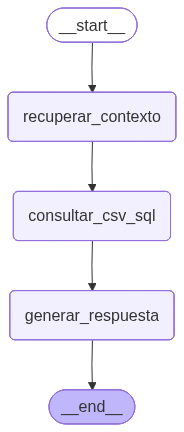

In [73]:
from IPython.display import Image, display

display(Image(agente_experto.get_graph().draw_mermaid_png()))

<a id="sec-16-5"></a>

### ***16.5 Funcion de chat con memoria***


In [74]:
# Historial simple usando mensajes de LangChain.
historial_conversacion = []


def formatear_historial(historial, max_mensajes=8):
    # Nos quedamos solo con los ultimos mensajes para que el prompt no crezca demasiado.
    mensajes_recientes = historial[-max_mensajes:]
    if not mensajes_recientes:
        return "No hay historial previo."

    # Convertimos mensajes HumanMessage/AIMessage/SystemMessage en texto legible.
    lineas = []
    for mensaje in mensajes_recientes:
        if isinstance(mensaje, HumanMessage):
            lineas.append(f"Usuario: {mensaje.content}")
        elif isinstance(mensaje, AIMessage):
            lineas.append(f"Asistente: {mensaje.content}")
        elif isinstance(mensaje, SystemMessage):
            lineas.append(f"Sistema: {mensaje.content}")
    return "\n".join(lineas)


# Funcion final para preguntar al agente.
def preguntar_agente(pregunta, thread_id="demo_usuario"):
    estado_inicial = {
        "pregunta": pregunta,
        "historial": formatear_historial(historial_conversacion),
        "contexto_rag": None,
        "fuentes_rag": None,
        "sql_generada": None,
        "datos_csv": None,
        "respuesta": None,
    }

    # thread_id identifica la conversacion en MemorySaver.
    config = {"configurable": {"thread_id": thread_id}}
    resultado = agente_experto.invoke(estado_inicial, config=config)

    # Guardamos el turno en una lista de mensajes, como en clase.
    historial_conversacion.append(HumanMessage(content=pregunta))
    historial_conversacion.append(AIMessage(content=resultado["respuesta"]))

    return resultado


<a id="sec-16-6"></a>

### ***16.6 Pruebas del agente final***


In [75]:
# Prueba opcional 1 del agente final.
# Comentada para reservar cuota para el chat interactivo y los ejemplos documentados.

# resultado_agente_precision = preguntar_agente("Que delantero tiene mayor precision de tiro?")
# print(resultado_agente_precision["respuesta"])


In [76]:
# Prueba opcional 2 del agente final.
# Comentada para reservar cuota para el chat interactivo y los ejemplos documentados.

# resultado_agente_xg = preguntar_agente("Cuales son los 5 jugadores con mas xG?")
# print(resultado_agente_xg["respuesta"])


In [77]:
# Prueba opcional de memoria conversacional.
# Comentada para reservar cuota. La memoria tambien se demuestra en los ejemplos finales.

# historial_conversacion.clear()
# respuesta_memoria_1 = preguntar_agente("Explica que significa PSxG+/- para evaluar porteros")
# print(respuesta_memoria_1["respuesta"])


In [78]:
# Pregunta opcional de seguimiento para memoria.
# Ejecutala solo si quieres probar la memoria antes de la seccion final.

# respuesta_memoria_2 = preguntar_agente("Y si esa metrica es positiva, que interpretacion tendria?")
# print(respuesta_memoria_2["respuesta"])


<a id="sec-16-7"></a>

### ***16.7 Verificacion de memoria y fuentes***


In [79]:
# Verificamos mensajes guardados.
for i, mensaje in enumerate(historial_conversacion, start=1):
    print(f"Mensaje {i}")
    print("Tipo:", type(mensaje).__name__)
    print("Contenido:", mensaje.content[:400], "...")
    print()

<a id="sec-17"></a>

## ***17. Interaccion en el notebook y ejemplos documentados***

Esta seccion cumple el Paso 6 del enunciado. Incluye una celda interactiva para conversar con el agente y cinco preguntas de ejemplo con sus respuestas documentadas.


<a id="sec-17-1"></a>

### ***17.1 Celda interactiva de chat***

La siguiente funcion permite hablar con el agente desde el notebook. Escribe preguntas una a una y usa `salir` para terminar la conversacion.


In [80]:
# Funcion interactiva para conversar con el agente desde el notebook.
def chat_interactivo(thread_id="chat_notebook"):
    # Mensaje inicial para el usuario.
    print("Chat iniciado. Escribe 'salir' para terminar.")

    # Bucle de conversacion.
    while True:
        # Leemos pregunta del usuario.
        pregunta = input("Usuario: ")

        # Permitimos salir del chat.
        if pregunta.lower().strip() in ["salir", "exit", "quit"]:
            print("Chat finalizado.")
            break

        # Si el usuario envia texto vacio, pedimos otra entrada.
        if not pregunta.strip():
            print("Escribe una pregunta o 'salir' para terminar.")
            continue

        # Ejecutamos el agente final con memoria.
        resultado = preguntar_agente(pregunta, thread_id=thread_id)

        # Mostramos la respuesta inmediata.
        print("Asistente:")
        print(resultado["respuesta"])
        print("" + "-" * 100 + "")

In [81]:
# Descomenta esta linea para iniciar una conversacion manual en el notebook.
chat_interactivo()


Chat iniciado. Escribe 'salir' para terminar.
Chat finalizado.


<a id="sec-17-2"></a>

### ***17.2 Cinco preguntas de ejemplo documentadas***

Estas preguntas cubren los casos principales del proyecto:

1. Pregunta conceptual con RAG.
2. Ranking con SQL generado por Gemini + RAG.
3. Comparacion de jugadores con SQL generado por Gemini + RAG.
4. Pregunta sobre porteros con RAG.
5. Pregunta de seguimiento para demostrar memoria.


Esta celda se deja comentada para evitar consumir cuota de Gemini. 
Las pruebas principales del agente ya se han realizado en el apartado 16.6 y 16.7.

In [82]:
# Reiniciamos la memoria para que los ejemplos sean reproducibles.
historial_conversacion.clear()

# Definimos cinco preguntas de evaluacion.
preguntas_ejemplo = [
    "Que significa xG y como se interpreta en scouting?",
    "Cuales son los jugadores con mas xG y que significa esta metrica?",
    "Compara a Mohamed Salah y Raphinha usando xG, xAG, PrgC y SCA",
    "Que significa PSxG+/- y como se usa para evaluar porteros?",
    "Y si esa metrica es positiva, que interpretacion tendria?",
]

# Ejecutamos las preguntas una a una con el mismo thread_id para conservar memoria.
respuestas_ejemplo = []
for i, pregunta in enumerate(preguntas_ejemplo, start=1):
    print("=" * 100)
    print(f"Pregunta {i}: {pregunta}")
    print("=" * 100)

    # Ejecutamos el agente.
    resultado = preguntar_agente(pregunta, thread_id="ejemplos_documentados")

    # Guardamos resultado para inspeccion posterior.
    respuestas_ejemplo.append(resultado)

    # Mostramos respuesta.
    print(resultado["respuesta"])
    print()

Pregunta 1: Que significa xG y como se interpreta en scouting?
El xG, o Goles Esperados, es una métrica avanzada que representa la suma de las probabilidades de gol de los tiros realizados por un jugador o equipo (Documento 1, Documento 4). En esencia, cuantifica la calidad de las ocasiones de gol generadas.

**Interpretación en scouting:**

En el scouting, el xG es fundamental para:

1.  **Evaluar la calidad de las ocasiones:** Permite determinar si un jugador se está posicionando bien para recibir balones en zonas de alto peligro o si tiene la capacidad de generar tiros desde situaciones con una alta probabilidad de terminar en gol (Documento 1, Documento 4).
2.  **Identificar la amenaza ofensiva real:** Un alto valor de xG indica que un jugador está generando muchas oportunidades de gol de calidad, independientemente de si las ha convertido o no. Esto es crucial para delanteros y extremos (Documento 3).
3.  **Comparar el rendimiento de finalización (G-xG):** Al comparar los goles an

<a id="resultado-fase"></a>

## ***Resultado de esta fase***

En este punto ya tenemos:

- 3 PDFs de metricas cargados como documentos de conocimiento.
- PDFs divididos en chunks semanticos.
- Embeddings creados con Gemini.
- Base vectorial persistente en ChromaDB.
- Retriever probado antes de conectar el agente.
- RAG basico con Gemini usando contexto recuperado desde los PDFs.
- CSV completo convertido en una tabla SQL temporal llamada `players`.
- Herramienta que genera SQL con Gemini, ejecuta la consulta con SQLite/pandas y devuelve resultados reales del CSV.
- Un unico agente final con LangGraph, SQL, ChromaDB, `HumanMessage`, `AIMessage` y `MemorySaver`.
- Celda interactiva de chat y 5 preguntas de ejemplo documentadas.


<a id="sec-18"></a>

## ***18. Conclusiones y mejoras futuras***

Esta seccion resume el resultado final del proyecto y plantea posibles mejoras para evolucionar el asistente mas alla del MVP.


<a id="sec-18-1"></a>

### ***18.1 Conclusiones***

El proyecto implementa un asistente experto en analitica de futbol profesional que combina conocimiento textual y datos estructurados. La parte RAG permite responder preguntas conceptuales sobre metricas avanzadas usando documentos PDF indexados en ChromaDB. La parte SQL permite consultar el CSV completo de jugadores para obtener rankings, comparaciones y valores numericos reales.

Las principales conclusiones son:

- El uso de RAG reduce la dependencia del conocimiento general del LLM y permite que las respuestas se apoyen en documentos propios.
- ChromaDB es adecuado para recuperar explicaciones de metricas, definiciones y contexto teorico.
- Para datos tabulares, como jugadores y estadisticas, es mas fiable consultar el CSV con pandas/SQLite que indexar todos los valores en una base vectorial.
- LangGraph permite organizar el sistema en pasos claros: recuperar contexto, consultar datos y generar respuesta.
- La memoria conversacional mejora la experiencia porque permite responder preguntas de seguimiento manteniendo el contexto anterior.
- El system prompt y la validacion de SQL ayudan a reducir alucinaciones y riesgos de ejecucion.

En conjunto, el notebook cumple el objetivo de construir un pipeline completo de IA generativa con RAG, agente conversacional y memoria.


<a id="sec-18-2"></a>

### ***18.2 Mejoras futuras***

Aunque el sistema ya funciona como MVP, se podria mejorar en varias direcciones:

- **Interfaz con Streamlit**: crear una aplicacion web sencilla para que el usuario pueda conversar con el agente sin abrir el notebook.
- **Mas documentos de conocimiento**: incluir informes tecnicos, documentacion de FBref, articulos de scouting o guias tacticas para enriquecer el RAG.
- **Evaluacion automatica**: crear un conjunto de preguntas de prueba y medir si el agente recupera las fuentes correctas y responde con datos coherentes.
- **Cache de consultas**: guardar respuestas o SQL frecuentes para reducir llamadas a Gemini y ahorrar cuota.
- **Mejor control de SQL**: anadir reglas mas avanzadas para revisar columnas, limites y filtros antes de ejecutar la consulta.
- **Uso de herramientas formales**: convertir la consulta SQL en una tool de LangChain/LangGraph para separar todavia mejor las responsabilidades del agente.
- **Mejor memoria**: guardar conversaciones por usuario o por sesion de forma persistente, no solo en memoria temporal.
- **Mejor visualizacion**: mostrar tablas, graficos y comparativas de jugadores para facilitar la interpretacion de resultados.
- **Actualizacion de datos**: permitir cargar nuevas temporadas o nuevos CSVs sin modificar el codigo principal.

Estas mejoras permitirian pasar de un prototipo academico funcional a una herramienta mas cercana a un producto real de analitica deportiva.
